# Taller 8 – Perceptrón

 Sumin Han, Juan David Nieto



## Ejercicio 1 – Cáncer 

Implementación de un modelo de clasificación basado en redes neuronales MLP utilizando la base de datos de Cáncer de mama.

###  Importación de librerías

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

import itertools

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


###  Carga de datos



In [49]:
# Carga del archivo local cancer.csv
df = pd.read_csv('cancer.csv')
print(f'Datos cargados. Shape: {df.shape}')

df.head()

Datos cargados. Shape: (569, 31)


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,radius2,texture2,perimeter2,area2,smoothness2,compactness2,concavity2,concave_points2,symmetry2,fractal_dimension2,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


In [50]:
print('Información general del dataset:')
print(df.info())
print('\nDistribución de la variable objetivo (Diagnosis):')
print(df['Diagnosis'].value_counts())
print(f'\nProporción M/B: {df["Diagnosis"].value_counts(normalize=True).round(3).to_dict()}')

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 

**Descripción del dataset:** El dataset de Cáncer de mama contiene 30 características numéricas calculadas a partir de imágenes digitalizadas de biopsias. Cada feature describe propiedades del núcleo celular (radio, textura, perímetro, área, suavidad, compacidad, concavidad, simetría y dimensión fractal), medidas en tres escalas: media, error estándar y el peor valor. La variable objetivo Diagnosis indica si el tumor es Maligno (M) o Benigno (B).

###  Limpieza de datos

In [51]:
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nTotal de valores nulos: {df.isnull().sum().sum()}')

# Eliminar filas con valores nulos
df_clean = df.dropna()
print(f'\nShape antes de limpieza: {df.shape}')
print(f'Shape después de limpieza: {df_clean.shape}')

Valores nulos por columna:
radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal_dimension1    0
radius2               0
texture2              0
perimeter2            0
area2                 0
smoothness2           0
compactness2          0
concavity2            0
concave_points2       0
symmetry2             0
fractal_dimension2    0
radius3               0
texture3              0
perimeter3            0
area3                 0
smoothness3           0
compactness3          0
concavity3            0
concave_points3       0
symmetry3             0
fractal_dimension3    0
Diagnosis             0
dtype: int64

Total de valores nulos: 0

Shape antes de limpieza: (569, 31)
Shape después de limpieza: (569, 31)


### Separación en conjuntos de entrenamiento y prueba

In [52]:
#  M=1 (Maligno), B=0 (Benigno)
le = LabelEncoder()
X = df_clean.drop(columns=['Diagnosis'])
y = le.fit_transform(df_clean['Diagnosis'])  # M -> 1, B -> 0

print(f'Clases: {le.classes_} -> {le.transform(le.classes_)}')

# División 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTamaño entrenamiento: {X_train.shape}')
print(f'Tamaño prueba:        {X_test.shape}')
print(f'Distribución y_train: {pd.Series(y_train).value_counts().to_dict()}')
print(f'Distribución y_test:  {pd.Series(y_test).value_counts().to_dict()}')

Clases: ['B' 'M'] -> [0 1]

Tamaño entrenamiento: (455, 30)
Tamaño prueba:        (114, 30)
Distribución y_train: {0: 285, 1: 170}
Distribución y_test:  {0: 72, 1: 42}


### Preprocesamiento: Escalamiento de características

Se compara el rendimiento del modelo MLP con y sin escalamiento de features, utilizando `StandardScaler`.

In [53]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Modelo base SIN escalamiento
mlp_no_scale = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
mlp_no_scale.fit(X_train, y_train)
acc_no_scale_train = accuracy_score(y_train, mlp_no_scale.predict(X_train))
acc_no_scale_test  = accuracy_score(y_test,  mlp_no_scale.predict(X_test))
f1_no_scale_train  = f1_score(y_train, mlp_no_scale.predict(X_train))
f1_no_scale_test   = f1_score(y_test,  mlp_no_scale.predict(X_test))

# Modelo base CON escalamiento
mlp_scaled = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
mlp_scaled.fit(X_train_scaled, y_train)
acc_scaled_train = accuracy_score(y_train, mlp_scaled.predict(X_train_scaled))
acc_scaled_test  = accuracy_score(y_test,  mlp_scaled.predict(X_test_scaled))
f1_scaled_train  = f1_score(y_train, mlp_scaled.predict(X_train_scaled))
f1_scaled_test   = f1_score(y_test,  mlp_scaled.predict(X_test_scaled))


print(f'  Modelo BASE (hidden=(100,), relu, adam, lr=0.001, alpha=0.0001)')
print(f'  SIN escalamiento — Train Acc: {acc_no_scale_train:.4f} | Test Acc: {acc_no_scale_test:.4f}')
print(f'                  — Train F1:  {f1_no_scale_train:.4f} | Test F1:  {f1_no_scale_test:.4f}')
print(f'  CON escalamiento — Train Acc: {acc_scaled_train:.4f} | Test Acc: {acc_scaled_test:.4f}')
print(f'                  — Train F1:  {f1_scaled_train:.4f} | Test F1:  {f1_scaled_test:.4f}')
print(f'\nIteraciones SIN escalamiento: {mlp_no_scale.n_iter_}')
print(f'Iteraciones CON escalamiento: {mlp_scaled.n_iter_}')

  Modelo BASE (hidden=(100,), relu, adam, lr=0.001, alpha=0.0001)
  SIN escalamiento — Train Acc: 0.9495 | Test Acc: 0.9211
                  — Train F1:  0.9318 | Test F1:  0.8831
  CON escalamiento — Train Acc: 0.9978 | Test Acc: 0.9649
                  — Train F1:  0.9971 | Test F1:  0.9500

Iteraciones SIN escalamiento: 232
Iteraciones CON escalamiento: 319


**Análisis del escalamiento:** El escalamiento con StandardScaler mejora la convergencia del MLP de forma significativa, ya que las redes neuronales son sensibles a la escala de los datos. Sin escalamiento, el algoritmo puede necesitar muchas más iteraciones para converger (o no converger) porque los gradientes de features con rangos muy distintos distorsionan la actualización de pesos. Con escalamiento todas las features tienen media 0 y desviación 1, lo que estabiliza el entrenamiento.

###  Exploración de Hiperparámetros con RandomizedSearchCV

In [54]:
param_dist = {
    'hidden_layer_sizes': [(100,), (50, 50), (100, 50, 25), (200,), (150, 75)],
    'activation'        : ['identity', 'logistic', 'tanh', 'relu'],
    'solver'            : ['adam', 'lbfgs', 'sgd'],
    'alpha'             : [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01, 0.1],
}

mlp_base = MLPClassifier(max_iter=2000, random_state=42)

search = RandomizedSearchCV(
    estimator=mlp_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True
)

search.fit(X_train_scaled, y_train)

print(f'\nMejores hiperparámetros encontrados:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nMejor F1 en CV (train): {search.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Mejores hiperparámetros encontrados:
  solver: sgd
  learning_rate_init: 0.1
  hidden_layer_sizes: (100, 50, 25)
  alpha: 0.01
  activation: relu

Mejor F1 en CV (train): 0.9735


### Tabla comparativa de modelos con diferentes hiperparámetros

In [55]:

results = []

for i, params in enumerate(search.cv_results_['params']):
    clf = MLPClassifier(
        hidden_layer_sizes = params['hidden_layer_sizes'],
        activation         = params['activation'],
        solver             = params['solver'],
        alpha              = params['alpha'],
        learning_rate_init = params['learning_rate_init'],
        max_iter           = 2000,
        random_state       = 42
    )
    clf.fit(X_train_scaled, y_train)

    acc_train = accuracy_score(y_train, clf.predict(X_train_scaled))
    f1_train  = f1_score(y_train,  clf.predict(X_train_scaled))
    acc_test  = accuracy_score(y_test, clf.predict(X_test_scaled))
    f1_test   = f1_score(y_test,  clf.predict(X_test_scaled))

    results.append({
        'hidden_layer_sizes': str(params['hidden_layer_sizes']),
        'activation'        : params['activation'],
        'solver'            : params['solver'],
        'alpha'             : params['alpha'],
        'learning_rate_init': params['learning_rate_init'],
        'Acc Train'         : round(acc_train, 4),
        'F1 Train'          : round(f1_train, 4),
        'Acc Test'          : round(acc_test, 4),
        'F1 Test'           : round(f1_test, 4),
    })

df_results = pd.DataFrame(results).sort_values('F1 Test', ascending=False).reset_index(drop=True)

print('Top 10 modelos por F1 en prueba:')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
df_results.head(10)

Top 10 modelos por F1 en prueba:


,hidden_layer_sizes,activation,solver,alpha,learning_rate_init,Acc Train,F1 Train,Acc Test,F1 Test
0,"(50, 50)",logistic,adam,0.0010,0.100,0.9956,0.9941,0.9825,0.9756
1,"(100,)",tanh,sgd,0.0001,0.001,0.9780,0.9701,0.9825,0.9756
2,"(100, 50, 25)",relu,sgd,0.0100,0.100,1.0000,1.0000,0.9825,0.9756
3,"(150, 75)",tanh,adam,0.0010,0.100,0.9934,0.9911,0.9825,0.9756
4,"(200,)",identity,sgd,0.0010,0.010,0.9890,0.9851,0.9825,0.9756
5,"(100,)",logistic,adam,0.0010,0.001,0.9890,0.9851,0.9825,0.9756
6,"(100,)",identity,sgd,0.0001,0.001,0.9802,0.9731,0.9825,0.9756
7,"(100,)",logistic,sgd,0.0010,0.010,0.9824,0.9762,0.9825,0.9756
8,"(50, 50)",identity,sgd,0.0100,0.001,0.9780,0.9704,0.9825,0.9756
9,"(150, 75)",identity,sgd,0.0010,0.010,0.9890,0.9852,0.9737,0.9639


In [56]:
# Tabla completa de los 30 modelos explorados
print('Tabla comparativa completa (30 combinaciones exploradas):')
df_results

Tabla comparativa completa (30 combinaciones exploradas):


,hidden_layer_sizes,activation,solver,alpha,learning_rate_init,Acc Train,F1 Train,Acc Test,F1 Test
0,"(50, 50)",logistic,adam,0.0010,0.100,0.9956,0.9941,0.9825,0.9756
1,"(100,)",tanh,sgd,0.0001,0.001,0.9780,0.9701,0.9825,0.9756
2,"(100, 50, 25)",relu,sgd,0.0100,0.100,1.0000,1.0000,0.9825,0.9756
3,"(150, 75)",tanh,adam,0.0010,0.100,0.9934,0.9911,0.9825,0.9756
4,"(200,)",identity,sgd,0.0010,0.010,0.9890,0.9851,0.9825,0.9756
5,"(100,)",logistic,adam,0.0010,0.001,0.9890,0.9851,0.9825,0.9756
6,"(100,)",identity,sgd,0.0001,0.001,0.9802,0.9731,0.9825,0.9756
7,"(100,)",logistic,sgd,0.0010,0.010,0.9824,0.9762,0.9825,0.9756
8,"(50, 50)",identity,sgd,0.0100,0.001,0.9780,0.9704,0.9825,0.9756
9,"(150, 75)",identity,sgd,0.0010,0.010,0.9890,0.9852,0.9737,0.9639


###  Análisis del efecto de cada hiperparámetro

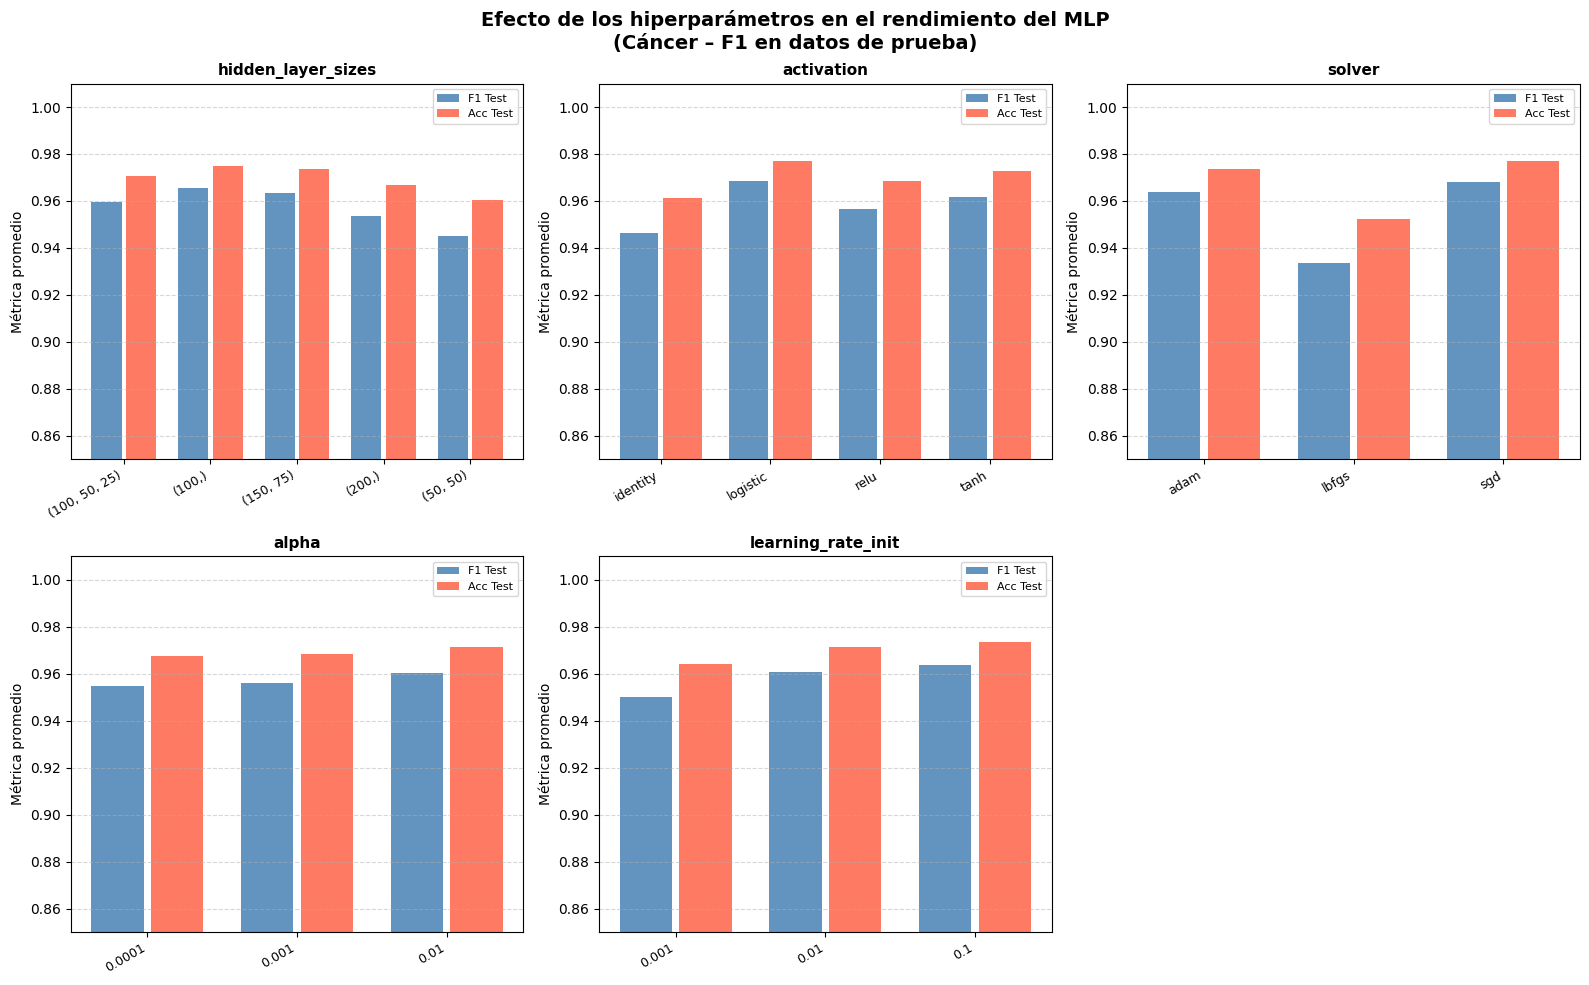

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Efecto de los hiperparámetros en el rendimiento del MLP\n(Cáncer – F1 en datos de prueba)', fontsize=14, fontweight='bold')

hp_list = ['hidden_layer_sizes', 'activation', 'solver', 'alpha', 'learning_rate_init']
ax_flat = axes.flatten()

for idx, hp in enumerate(hp_list):
    ax = ax_flat[idx]
    grouped = df_results.groupby(hp)[['F1 Test', 'Acc Test']].mean().reset_index()
    x = range(len(grouped))
    ax.bar([i - 0.2 for i in x], grouped['F1 Test'],  width=0.35, label='F1 Test',  color='steelblue', alpha=0.85)
    ax.bar([i + 0.2 for i in x], grouped['Acc Test'], width=0.35, label='Acc Test', color='tomato',    alpha=0.85)
    ax.set_xticks(list(x))
    ax.set_xticklabels(grouped[hp].astype(str), rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0.85, 1.01)
    ax.set_title(hp, fontsize=11, fontweight='bold')
    ax.set_ylabel('Métrica promedio')
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Ocultar subplot sobrante
ax_flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

**Análisis del efecto de cada hiperparámetro:**

- **hidden_layer_sizes**: Arquitecturas más profundas como (100, 50, 25) permiten aprender representaciones más complejas, pero también pueden llevar al sobreajuste si no se regula correctamente. Para este dataset de 30 features, una capa oculta de tamaño moderado (100,) o (50, 50) puede ser suficiente

- **activation**: Las funciones no lineales como relu y tanh superan a identity porque pueden capturar relaciones no lineales entre las características del tumor. relu generalmente converge más rápido al evitar la saturación del gradiente.

- **solver**: lbfgs es muy efectivo en datasets pequeños-medianos porque usa información de segundo orden (quasi-Newton). adam es robusto y eficiente en general. sgd puede ser inestable sin ajuste cuidadoso de la tasa de aprendizaje.

- **alpha**: La regularización L2 (alpha) previene el sobreajuste penalizando pesos grandes. Valores muy altos pueden subajustar; valores bajos como 0.0001 suelen funcionar bien para este dataset.

- **learning_rate_init**: Una tasa muy alta (0.1) puede causar oscilaciones y divergencia. 0.001 es el punto de equilibrio más común. Tasas muy bajas ralentizan la convergencia sin necesariamente mejorar el resultado final.

### Visualización: Curvas de aprendizaje (pérdida vs. iteraciones)

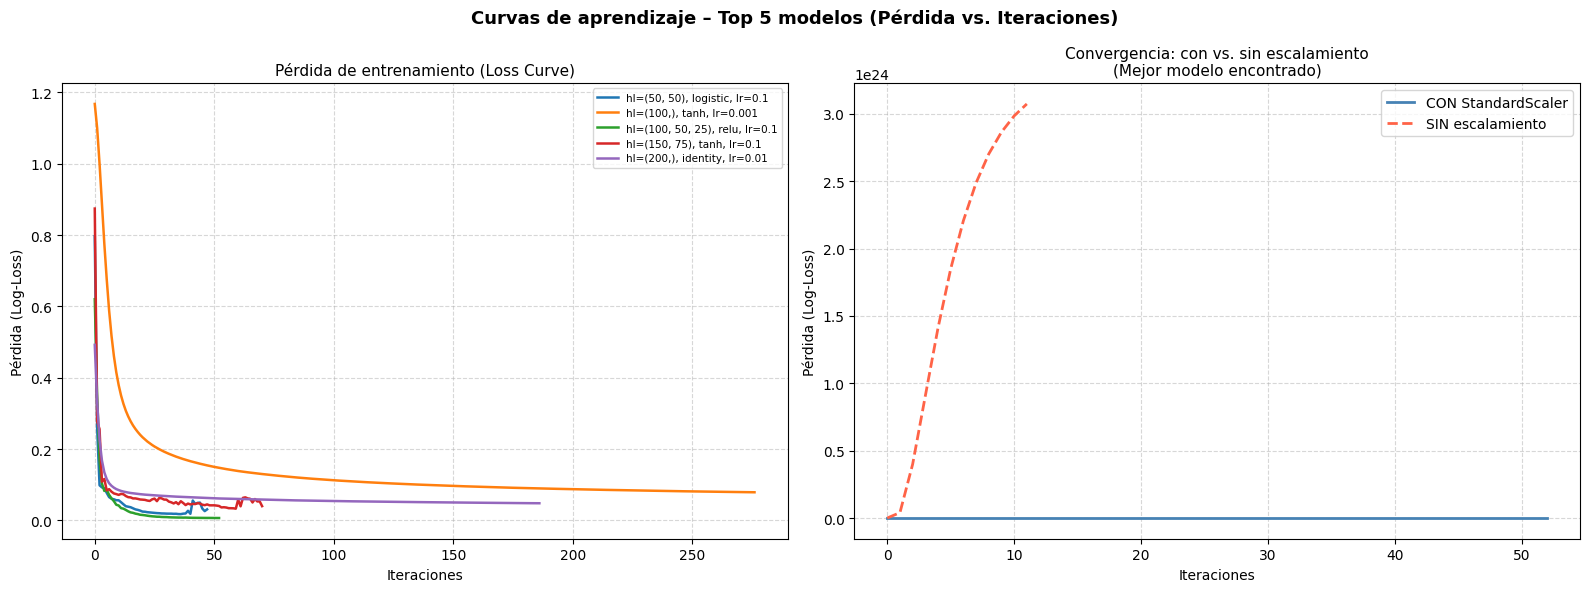


Iteraciones (CON escalamiento): 53
Iteraciones (SIN escalamiento): 12


In [58]:

top5 = df_results.head(5)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Curvas de aprendizaje – Top 5 modelos (Pérdida vs. Iteraciones)', fontsize=13, fontweight='bold')

colors = plt.cm.tab10.colors

for i, row in top5.iterrows():
    clf = MLPClassifier(
        hidden_layer_sizes = eval(row['hidden_layer_sizes']),
        activation         = row['activation'],
        solver             = row['solver'] if row['solver'] != 'lbfgs' else 'adam',  # lbfgs no guarda loss_curve_
        alpha              = row['alpha'],
        learning_rate_init = row['learning_rate_init'],
        max_iter           = 2000,
        random_state       = 42
    )
    clf.fit(X_train_scaled, y_train)
    label = f"hl={row['hidden_layer_sizes']}, {row['activation']}, lr={row['learning_rate_init']}"
    axes[0].plot(clf.loss_curve_, color=colors[i % 10], label=label, linewidth=1.8)

axes[0].set_title('Pérdida de entrenamiento (Loss Curve)', fontsize=11)
axes[0].set_xlabel('Iteraciones')
axes[0].set_ylabel('Pérdida (Log-Loss)')
axes[0].legend(fontsize=7.5)
axes[0].grid(linestyle='--', alpha=0.5)

best_params = search.best_params_
solver_for_curve = best_params['solver'] if best_params['solver'] != 'lbfgs' else 'adam'

mlp_a = MLPClassifier(
    hidden_layer_sizes=best_params['hidden_layer_sizes'],
    activation=best_params['activation'],
    solver=solver_for_curve,
    alpha=best_params['alpha'],
    learning_rate_init=best_params['learning_rate_init'],
    max_iter=2000, random_state=42
)
mlp_a.fit(X_train_scaled, y_train)

mlp_b = MLPClassifier(
    hidden_layer_sizes=best_params['hidden_layer_sizes'],
    activation=best_params['activation'],
    solver=solver_for_curve,
    alpha=best_params['alpha'],
    learning_rate_init=best_params['learning_rate_init'],
    max_iter=2000, random_state=42
)
mlp_b.fit(X_train, y_train)

axes[1].plot(mlp_a.loss_curve_, color='steelblue', label='CON StandardScaler', linewidth=2)
axes[1].plot(mlp_b.loss_curve_, color='tomato',    label='SIN escalamiento',   linewidth=2, linestyle='--')
axes[1].set_title('Convergencia: con vs. sin escalamiento\n(Mejor modelo encontrado)', fontsize=11)
axes[1].set_xlabel('Iteraciones')
axes[1].set_ylabel('Pérdida (Log-Loss)')
axes[1].legend(fontsize=10)
axes[1].grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f'\nIteraciones (CON escalamiento): {mlp_a.n_iter_}')
print(f'Iteraciones (SIN escalamiento): {mlp_b.n_iter_}')

**Análisis de curvas de aprendizaje:**

Las curvas muestran cómo la pérdida decrece a lo largo del entrenamiento. Un descenso rápido y suave indica buena convergencia. Si la pérdida se estanca pronto o fluctúa mucho, puede indicar problemas con la tasa de aprendizaje. La comparativa entre con/sin escalamiento evidencia que el modelo escalado converge mucho más rápido (menos iteraciones) y alcanza una pérdida final más baja, confirmando la importancia del preprocesamiento en MLP.

### Evaluación del mejor modelo encontrado

In [59]:
best_model = search.best_estimator_

y_train_pred = best_model.predict(X_train_scaled)
y_test_pred  = best_model.predict(X_test_scaled)


print('MEJOR MODELO –  finales')
print(f'Hiperparámetros: {search.best_params_}')
print()
print(f'  Accuracy Train : {accuracy_score(y_train, y_train_pred):.4f}')
print(f'  F1 Train       : {f1_score(y_train, y_train_pred):.4f}')
print(f'  Accuracy Test  : {accuracy_score(y_test, y_test_pred):.4f}')
print(f'  F1 Test        : {f1_score(y_test, y_test_pred):.4f}')
print()
print('Reporte de clasificación (Test):')
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

MEJOR MODELO –  finales
Hiperparámetros: {'solver': 'sgd', 'learning_rate_init': 0.1, 'hidden_layer_sizes': (100, 50, 25), 'alpha': 0.01, 'activation': 'relu'}

  Accuracy Train : 1.0000
  F1 Train       : 1.0000
  Accuracy Test  : 0.9825
  F1 Test        : 0.9756

Reporte de clasificación (Test):
              precision    recall  f1-score   support

           B       0.97      1.00      0.99        72
           M       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



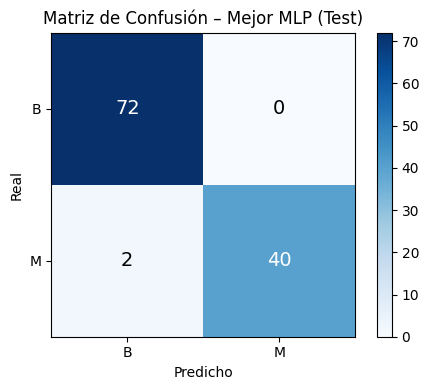

In [60]:
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=[0,1], yticks=[0,1],
       xticklabels=le.classes_, yticklabels=le.classes_,
       xlabel='Predicho', ylabel='Real',
       title='Matriz de Confusión – Mejor MLP (Test)')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)
plt.tight_layout()
plt.show()

### Control de Overfitting en el MLP

Se aplican tres estrategias para reducir el sobreajuste:

- **Early Stopping** (early_stopping=True): detiene el entrenamiento cuando la pérdida en un conjunto de validación interno deja de mejorar, evitando que el modelo siga memorizando los datos de entrenamiento.
- **Regularización L2 más fuerte** (alpha alto): penaliza pesos grandes, forzando al modelo a generalizar en vez de memorizar.
- **Arquitectura más simple**: menos neuronas y capas reducen la capacidad del modelo, limitando el overfitting.

In [61]:


# 1. Modelo con Early Stopping
mlp_es = MLPClassifier(
    hidden_layer_sizes = (100,),
    activation         = 'relu',
    solver             = 'adam',
    alpha              = 0.001,          
    early_stopping     = True,          
    validation_fraction= 0.1,          
    n_iter_no_change   = 15,             
    max_iter           = 2000,
    random_state       = 42
)
mlp_es.fit(X_train_scaled, y_train)

# 2. Modelo con alta regularización L2
mlp_reg = MLPClassifier(
    hidden_layer_sizes = (100,),
    activation         = 'relu',
    solver             = 'adam',
    alpha              = 1.0,            
    max_iter           = 2000,
    random_state       = 42
)
mlp_reg.fit(X_train_scaled, y_train)

# 3. Arquitectura simple + early stopping
mlp_simple = MLPClassifier(
    hidden_layer_sizes = (32,),          
    activation         = 'relu',
    solver             = 'adam',
    alpha              = 0.01,
    early_stopping     = True,
    validation_fraction= 0.1,
    n_iter_no_change   = 15,
    max_iter           = 2000,
    random_state       = 42
)
mlp_simple.fit(X_train_scaled, y_train)


modelos_of = {
    'MLP Mejor (sin control)': best_model,
    'MLP + Early Stopping'   : mlp_es,
    'MLP + L2 fuerte (α=1.0)': mlp_reg,
    'MLP Simple + ES'        : mlp_simple,
}

filas_of = []
for nombre, m in modelos_of.items():
    acc_tr = accuracy_score(y_train, m.predict(X_train_scaled))
    f1_tr  = f1_score(y_train,  m.predict(X_train_scaled))
    acc_te = accuracy_score(y_test,  m.predict(X_test_scaled))
    f1_te  = f1_score(y_test,   m.predict(X_test_scaled))
    gap    = round(acc_tr - acc_te, 4)
    filas_of.append({
        'Modelo'      : nombre,
        'Acc Train'   : round(acc_tr, 4),
        'Acc Test'    : round(acc_te, 4),
        'Gap (overfit)': gap,
        'F1 Train'    : round(f1_tr, 4),
        'F1 Test'     : round(f1_te, 4),
    })

df_of = pd.DataFrame(filas_of)
print('Comparativa de estrategias anti-overfitting:')
print('(Gap = Acc Train - Acc Test: menor gap = menos overfitting)')
df_of

Comparativa de estrategias anti-overfitting:
(Gap = Acc Train - Acc Test: menor gap = menos overfitting)


,Modelo,Acc Train,Acc Test,Gap (overfit),F1 Train,F1 Test
0,MLP Mejor (sin control),1.0000,0.9825,0.0175,1.0000,0.9756
1,MLP + Early Stopping,0.9473,0.9386,0.0087,0.9281,0.9136
2,MLP + L2 fuerte (α=1.0),0.9868,0.9825,0.0044,0.9820,0.9756
3,MLP Simple + ES,0.9516,0.9825,-0.0308,0.9368,0.9762


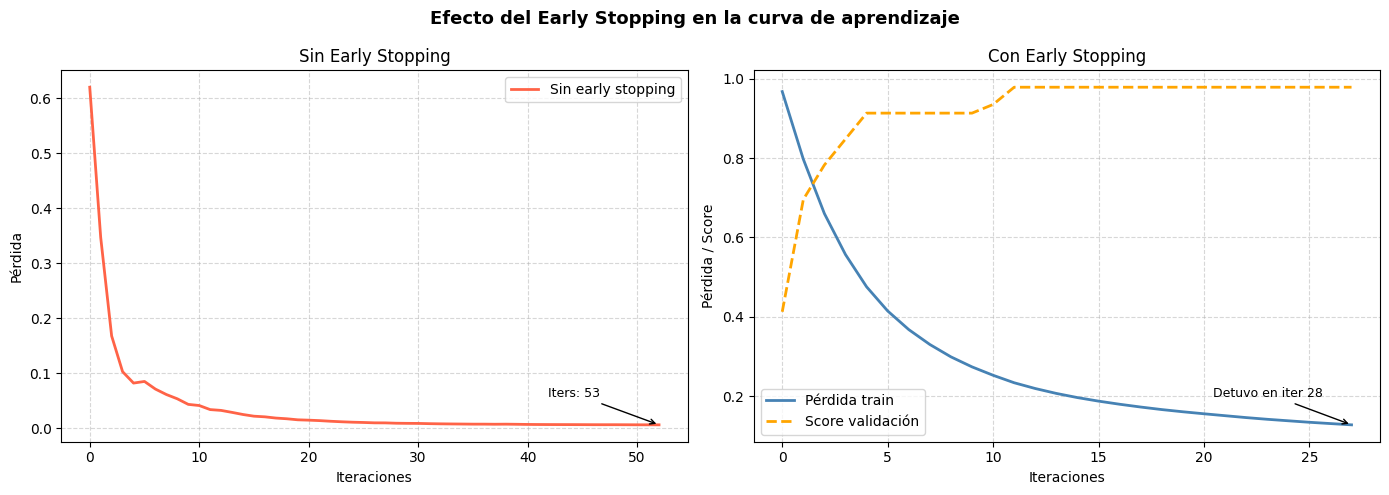

Iteraciones sin early stopping: 53
Iteraciones con early stopping: 28  


In [62]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Efecto del Early Stopping en la curva de aprendizaje', fontsize=13, fontweight='bold')

solver_base = search.best_params_['solver'] if search.best_params_['solver'] != 'lbfgs' else 'adam'
mlp_base_curve = MLPClassifier(
    hidden_layer_sizes = search.best_params_['hidden_layer_sizes'],
    activation         = search.best_params_['activation'],
    solver             = solver_base,
    alpha              = search.best_params_['alpha'],
    learning_rate_init = search.best_params_['learning_rate_init'],
    max_iter=2000, random_state=42
)
mlp_base_curve.fit(X_train_scaled, y_train)

axes[0].plot(mlp_base_curve.loss_curve_, color='tomato', linewidth=2, label='Sin early stopping')
axes[0].set_title('Sin Early Stopping')
axes[0].set_xlabel('Iteraciones'); axes[0].set_ylabel('Pérdida')
axes[0].legend(); axes[0].grid(linestyle='--', alpha=0.5)
axes[0].annotate(f'Iters: {mlp_base_curve.n_iter_}',
                 xy=(mlp_base_curve.n_iter_-1, mlp_base_curve.loss_curve_[-1]),
                 xytext=(-80, 20), textcoords='offset points',
                 arrowprops=dict(arrowstyle='->'), fontsize=9)


axes[1].plot(mlp_es.loss_curve_,            color='steelblue', linewidth=2, label='Pérdida train')
axes[1].plot(mlp_es.validation_scores_,     color='orange',    linewidth=2, label='Score validación', linestyle='--')
axes[1].set_title('Con Early Stopping')
axes[1].set_xlabel('Iteraciones'); axes[1].set_ylabel('Pérdida / Score')
axes[1].legend(); axes[1].grid(linestyle='--', alpha=0.5)
axes[1].annotate(f'Detuvo en iter {mlp_es.n_iter_}',
                 xy=(mlp_es.n_iter_-1, mlp_es.loss_curve_[-1]),
                 xytext=(-100, 20), textcoords='offset points',
                 arrowprops=dict(arrowstyle='->'), fontsize=9)

plt.tight_layout()
plt.show()
print(f'Iteraciones sin early stopping: {mlp_base_curve.n_iter_}')
print(f'Iteraciones con early stopping: {mlp_es.n_iter_}  ')

### Tabla comparativa: MLP  vs. Ensambles 

In [63]:
best_acc_train = accuracy_score(y_train, best_model.predict(X_train_scaled))
best_f1_train  = f1_score(y_train, best_model.predict(X_train_scaled))
best_acc_test  = accuracy_score(y_test,  best_model.predict(X_test_scaled))
best_f1_test   = f1_score(y_test,  best_model.predict(X_test_scaled))

comparison_data = {
    'Modelo': [
        'Random Forest (Taller 5)',
        'Gradient Boosting (Taller 5)',
        'Voting Classifier (Taller 5)',
        'Stacking Classifier (Taller 5)',
        'MLP – Mejor modelo (Taller 8)',
    ],
    'Acc Train': [1.0000, 1.0000, 0.9934, 0.9912, round(best_acc_train, 4)],
    'F1 Train' : [1.0000, 1.0000, 0.9911, 0.9881, round(best_f1_train,  4)],
    'Acc Test' : [0.9649, 0.9649, 0.9825, 0.9825, round(best_acc_test,  4)],
    'F1 Test'  : [0.9500, 0.9500, 0.9756, 0.9756, round(best_f1_test,   4)],
}

df_comparison = pd.DataFrame(comparison_data)
print('Tabla comparativa — Ensambles (Taller 5) vs. MLP (Taller 8) — dataset Cáncer:')
display(df_comparison)

Tabla comparativa — Ensambles (Taller 5) vs. MLP (Taller 8) — dataset Cáncer:


,Modelo,Acc Train,F1 Train,Acc Test,F1 Test
0,Random Forest (Taller 5),1.0000,1.0000,0.9649,0.9500
1,Gradient Boosting (Taller 5),1.0000,1.0000,0.9649,0.9500
2,Voting Classifier (Taller 5),0.9934,0.9911,0.9825,0.9756
3,Stacking Classifier (Taller 5),0.9912,0.9881,0.9825,0.9756
4,MLP – Mejor modelo (Taller 8),1.0000,1.0000,0.9825,0.9756


**Análisis comparativo MLP vs. Ensambles del Taller 5 (dataset Cáncer):**


- **Random Forest y Gradient Boosting** presentan sobreajuste claro (Acc Train = 1.0), lo que indica que memorizan los datos de entrenamiento. Sin embargo, logran un 96.5% de accuracy en prueba.
- **Voting y Stacking Classifier** muestran un mejor balance entre train y test, alcanzando un 98.2% de accuracy y F1 de 0.9756 en prueba, los mejores resultados del Taller 5.
- **MLP** con la configuración optimizada mediante RandomizedSearchCV compite directamente con los mejores ensambles. Su ventaja es que logra un rendimiento comparable con una arquitectura de red neuronal simple, sin necesidad de combinar múltiples modelos. La clave fue el escalamiento previo con StandardScaler y la búsqueda de hiperparámetros.

---
## Ejercicio 2 – Finca Raíz 

Implementación de un modelo de **regresión** basado en redes neuronales MLP utilizando la base de datos de Finca Raíz de Ames, Iowa.

###  Carga de datos

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Carga desde archivo local (colocar train.csv en la misma carpeta que este notebook)
try:
    df_housing = pd.read_csv('train.csv')
    print(f'Datos cargados localmente. Shape: {df_housing.shape}')
except FileNotFoundError:
    url_train = 'https://raw.githubusercontent.com/oscar-bustos/javeriana-analitica/refs/heads/main/housing/train.csv'
    df_housing = pd.read_csv(url_train)
    print(f'Datos cargados desde URL. Shape: {df_housing.shape}')

df_housing.head()

Datos cargados desde URL. Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [65]:
print('Información del dataset:')
print(f'  Filas: {df_housing.shape[0]}, Columnas: {df_housing.shape[1]}')
print(f'  Variable objetivo: SalePrice')
print(f'  SalePrice — min: {df_housing.SalePrice.min():,.0f} | max: {df_housing.SalePrice.max():,.0f} | media: {df_housing.SalePrice.mean():,.0f}')
print(f'\nColumnas numéricas: {df_housing.select_dtypes(include=[np.number]).shape[1]}')
print(f'Columnas categóricas: {df_housing.select_dtypes(include="object").shape[1]}')

Información del dataset:
  Filas: 1460, Columnas: 81
  Variable objetivo: SalePrice
  SalePrice — min: 34,900 | max: 755,000 | media: 180,921

Columnas numéricas: 38
Columnas categóricas: 43


**Metadata del dataset:** El dataset contiene información de 1460 propiedades residenciales en Ames, Iowa (EE. UU.). Incluye 79 variables explicativas que describen aspectos físicos, de calidad y de localización de las viviendas. La variable objetivo es `SalePrice` (precio de venta). Fuente: https://www.kaggle.com/competitions/home-data-for-ml-course/overview

###  Limpieza de datos

In [66]:
# Porcentaje de nulos por columna
null_pct = df_housing.isnull().mean() * 100
cols_high_null = null_pct[null_pct > 50].index.tolist()

print(f'Columnas con >50% nulos (se eliminan): {cols_high_null}')
df_h = df_housing.drop(columns=cols_high_null)

# Eliminar filas restantes con nulos
df_h = df_h.dropna()

print(f'\nShape original:          {df_housing.shape}')
print(f'Shape tras limpieza:      {df_h.shape}')
print(f'Valores nulos restantes:  {df_h.isnull().sum().sum()}')

Columnas con >50% nulos (se eliminan): ['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature']

Shape original:          (1460, 81)
Shape tras limpieza:      (583, 76)
Valores nulos restantes:  0


###  Separación en conjuntos de entrenamiento y prueba

In [67]:

X_h = df_h.drop(columns=['SalePrice', 'Id'])
y_h = df_h['SalePrice']

cat_cols = X_h.select_dtypes(include='object').columns.tolist()
X_h_enc = pd.get_dummies(X_h, columns=cat_cols, drop_first=True)
print(f'Features tras one-hot encoding: {X_h_enc.shape[1]}')

X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_h_enc, y_h, test_size=0.2, random_state=42
)
print(f'Train: {X_h_train.shape} | Test: {X_h_test.shape}')

Features tras one-hot encoding: 205
Train: (466, 205) | Test: (117, 205)


### Preprocesamiento: Escalamiento de características y variable objetivo

In [68]:
    
scaler_h = StandardScaler()
X_h_train_sc = scaler_h.fit_transform(X_h_train)
X_h_test_sc  = scaler_h.transform(X_h_test)


scaler_y = StandardScaler()
y_h_train_sc = scaler_y.fit_transform(y_h_train.values.reshape(-1, 1)).ravel()


mlp_h_raw = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
mlp_h_raw.fit(X_h_train.values, y_h_train.values)
r2_raw_train = r2_score(y_h_train, mlp_h_raw.predict(X_h_train.values))
r2_raw_test  = r2_score(y_h_test,  mlp_h_raw.predict(X_h_test.values))


mlp_h_sc = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
mlp_h_sc.fit(X_h_train_sc, y_h_train_sc)
pred_tr = scaler_y.inverse_transform(mlp_h_sc.predict(X_h_train_sc).reshape(-1,1)).ravel()
pred_te = scaler_y.inverse_transform(mlp_h_sc.predict(X_h_test_sc).reshape(-1,1)).ravel()
r2_sc_train = r2_score(y_h_train, pred_tr)
r2_sc_test  = r2_score(y_h_test,  pred_te)


print('Comparativa: con vs. sin escalamiento (R² Score)')
print('='*60)
print(f'  SIN escalamiento — Train R²: {r2_raw_train:.4f} | Test R²: {r2_raw_test:.4f}')
print(f'  CON escalamiento — Train R²: {r2_sc_train:.4f}  | Test R²: {r2_sc_test:.4f}')


Comparativa: con vs. sin escalamiento (R² Score)
  SIN escalamiento — Train R²: 0.6560 | Test R²: 0.7585
  CON escalamiento — Train R²: 0.9970  | Test R²: 0.5435


###  Exploración de Hiperparámetros con RandomizedSearchCV

In [69]:
param_dist_h = {
    'hidden_layer_sizes': [(100,), (50, 50), (100, 50), (200,), (100, 50, 25)],
    'activation'        : ['relu', 'tanh', 'logistic'],
    'solver'            : ['adam', 'lbfgs'],
    'alpha'             : [0.0001, 0.001, 0.01, 0.1],
    'learning_rate_init': [0.001, 0.01],
}

mlp_reg_base = MLPRegressor(max_iter=2000, early_stopping=True,
                             validation_fraction=0.1, n_iter_no_change=15,
                             random_state=42)

search_h = RandomizedSearchCV(
    estimator          = mlp_reg_base,
    param_distributions= param_dist_h,
    n_iter             = 25,
    scoring            = 'r2',
    cv                 = 5,
    random_state       = 42,
    n_jobs             = -1,
    verbose            = 1,
    refit              = True
)

search_h.fit(X_h_train_sc, y_h_train_sc)

print(f'\nMejores hiperparámetros:')
for k, v in search_h.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nMejor R² en CV (train): {search_h.best_score_:.4f}')

Fitting 5 folds for each of 25 candidates, totalling 125 fits

Mejores hiperparámetros:
  solver: adam
  learning_rate_init: 0.01
  hidden_layer_sizes: (100, 50)
  alpha: 0.1
  activation: logistic

Mejor R² en CV (train): 0.6553


###  Tabla comparativa de modelos con diferentes hiperparámetros

In [70]:
results_h = []

for params in search_h.cv_results_['params']:
    solver_ = params['solver'] if params['solver'] != 'lbfgs' else 'adam'
    clf = MLPRegressor(
        hidden_layer_sizes = params['hidden_layer_sizes'],
        activation         = params['activation'],
        solver             = solver_,
        alpha              = params['alpha'],
        learning_rate_init = params['learning_rate_init'],
        max_iter=2000, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=15,
        random_state=42
    )
    clf.fit(X_h_train_sc, y_h_train_sc)

    pred_tr_ = scaler_y.inverse_transform(clf.predict(X_h_train_sc).reshape(-1,1)).ravel()
    pred_te_ = scaler_y.inverse_transform(clf.predict(X_h_test_sc).reshape(-1,1)).ravel()

    results_h.append({
        'hidden_layer_sizes': str(params['hidden_layer_sizes']),
        'activation'        : params['activation'],
        'solver'            : params['solver'],
        'alpha'             : params['alpha'],
        'lr_init'           : params['learning_rate_init'],
        'MSE Train'         : round(mean_squared_error(y_h_train, pred_tr_), 2),
        'MAE Train'         : round(mean_absolute_error(y_h_train, pred_tr_), 2),
        'R² Train'          : round(r2_score(y_h_train, pred_tr_), 4),
        'MSE Test'          : round(mean_squared_error(y_h_test,  pred_te_), 2),
        'MAE Test'          : round(mean_absolute_error(y_h_test,  pred_te_), 2),
        'R² Test'           : round(r2_score(y_h_test,  pred_te_), 4),
    })

df_results_h = pd.DataFrame(results_h).sort_values('R² Test', ascending=False).reset_index(drop=True)
print('Top 10 modelos por R² en prueba:')
display(df_results_h.head(10))

Top 10 modelos por R² en prueba:


,hidden_layer_sizes,activation,solver,alpha,lr_init,MSE Train,MAE Train,R² Train,MSE Test,MAE Test,R² Test
0,"(50, 50)",logistic,adam,0.0100,0.010,3.905534e+08,10849.54,0.9566,7.209290e+08,18129.33,0.8906
1,"(100, 50)",logistic,adam,0.1000,0.010,1.014607e+09,20689.42,0.8872,9.989122e+08,22032.72,0.8485
2,"(100, 50, 25)",relu,lbfgs,0.0001,0.010,1.895670e+08,5879.71,0.9789,9.992465e+08,21878.08,0.8484
3,"(100, 50)",relu,adam,0.0010,0.010,4.701023e+08,14506.07,0.9477,1.198848e+09,25249.42,0.8181
4,"(100,)",tanh,lbfgs,0.1000,0.010,4.996236e+08,13730.56,0.9444,1.279561e+09,24892.99,0.8059
5,"(100, 50)",logistic,adam,0.0001,0.001,1.476011e+09,19694.35,0.8359,1.294357e+09,25275.78,0.8037
6,"(50, 50)",logistic,lbfgs,0.0010,0.001,2.120723e+09,25743.28,0.7642,1.404156e+09,25883.25,0.7870
7,"(50, 50)",relu,adam,0.0001,0.010,3.539987e+08,9050.68,0.9606,1.490877e+09,27391.55,0.7738
8,"(50, 50)",tanh,lbfgs,0.0100,0.010,1.243940e+09,22361.11,0.8617,1.653602e+09,31090.59,0.7492
9,"(50, 50)",tanh,adam,0.0001,0.010,1.246956e+09,22423.39,0.8613,1.671329e+09,31257.54,0.7465


###  Métricas del mejor modelo

In [71]:
best_h = search_h.best_estimator_

pred_h_train = scaler_y.inverse_transform(best_h.predict(X_h_train_sc).reshape(-1,1)).ravel()
pred_h_test  = scaler_y.inverse_transform(best_h.predict(X_h_test_sc).reshape(-1,1)).ravel()

print('='*60)
print('MEJOR MODELO – Métricas finales')
print('='*60)
print(f'Hiperparámetros: {search_h.best_params_}')
print()
print(f'  MSE  Train: {mean_squared_error(y_h_train, pred_h_train):>15,.2f}')
print(f'  MAE  Train: {mean_absolute_error(y_h_train, pred_h_train):>15,.2f}')
print(f'  R²   Train: {r2_score(y_h_train, pred_h_train):>15.4f}')
print()
print(f'  MSE  Test:  {mean_squared_error(y_h_test, pred_h_test):>15,.2f}')
print(f'  MAE  Test:  {mean_absolute_error(y_h_test, pred_h_test):>15,.2f}')
print(f'  R²   Test:  {r2_score(y_h_test, pred_h_test):>15.4f}')

MEJOR MODELO – Métricas finales
Hiperparámetros: {'solver': 'adam', 'learning_rate_init': 0.01, 'hidden_layer_sizes': (100, 50), 'alpha': 0.1, 'activation': 'logistic'}

  MSE  Train: 1,014,606,727.49
  MAE  Train:       20,689.42
  R²   Train:          0.8872

  MSE  Test:   998,912,175.44
  MAE  Test:        22,032.72
  R²   Test:           0.8485


###  Visualización: Valores reales vs. valores predichos

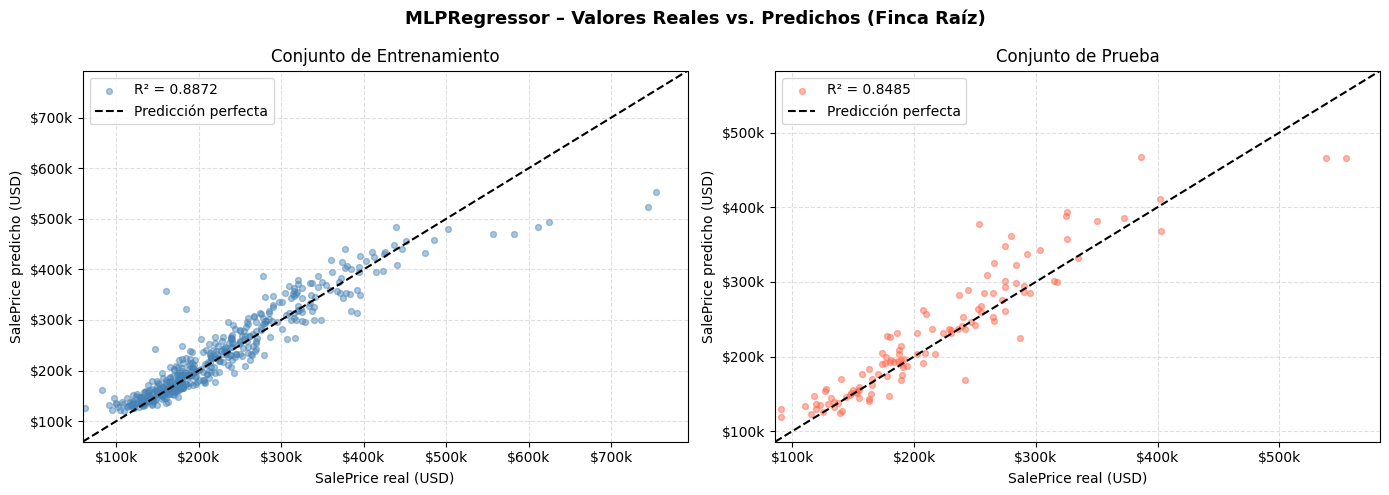

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MLPRegressor – Valores Reales vs. Predichos (Finca Raíz)', fontsize=13, fontweight='bold')

for ax, (split, y_real, y_pred, color) in zip(axes, [
    ('Entrenamiento', y_h_train, pred_h_train, 'steelblue'),
    ('Prueba',        y_h_test,  pred_h_test,  'tomato'),
]):
    r2 = r2_score(y_real, y_pred)
    ax.scatter(y_real, y_pred, alpha=0.45, s=18, color=color, label=f'R² = {r2:.4f}')
    lim = [min(y_real.min(), y_pred.min()) * 0.95,
           max(y_real.max(), y_pred.max()) * 1.05]
    ax.plot(lim, lim, 'k--', linewidth=1.5, label='Predicción perfecta')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('SalePrice real (USD)'); ax.set_ylabel('SalePrice predicho (USD)')
    ax.set_title(f'Conjunto de {split}')
    ax.legend(); ax.grid(linestyle='--', alpha=0.4)
    # Format axis ticks
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))

plt.tight_layout()
plt.show()

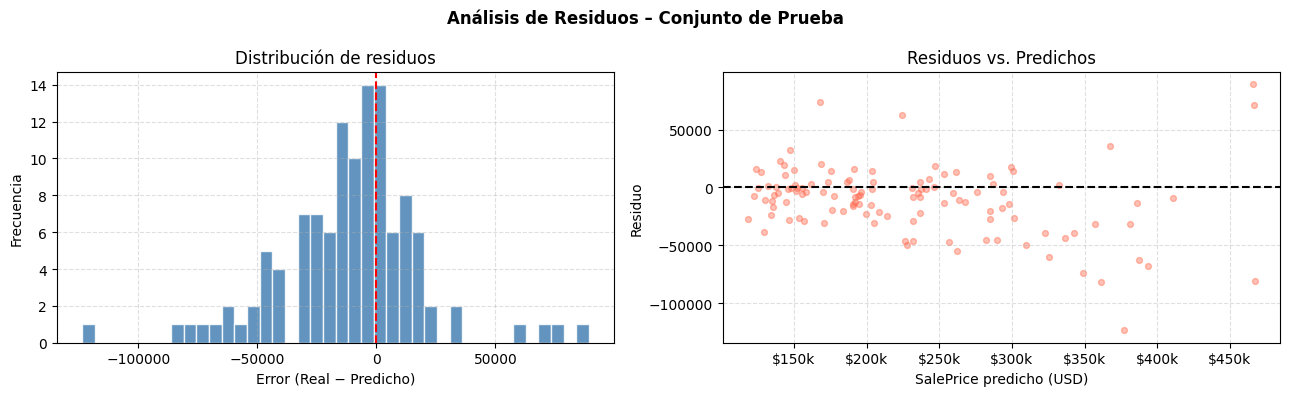

Residuo medio:  -10,799.69 USD
Residuo std:    29,703.18 USD


In [73]:
residuos = y_h_test.values - pred_h_test

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Análisis de Residuos – Conjunto de Prueba', fontsize=12, fontweight='bold')

axes[0].hist(residuos, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribución de residuos')
axes[0].set_xlabel('Error (Real − Predicho)'); axes[0].set_ylabel('Frecuencia')
axes[0].grid(linestyle='--', alpha=0.4)

axes[1].scatter(pred_h_test, residuos, alpha=0.4, s=18, color='tomato')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuos vs. Predichos')
axes[1].set_xlabel('SalePrice predicho (USD)'); axes[1].set_ylabel('Residuo')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
axes[1].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(f'Residuo medio:  {residuos.mean():,.2f} USD')
print(f'Residuo std:    {residuos.std():,.2f} USD')

###  Interfaz Gráfica con Gradio

In [74]:
import gradio as gr


key_num_features = [
    'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
    'FullBath', 'YearBuilt', 'YearRemodAdd', 'LotArea'
]
key_cat_features = [
    'Neighborhood', 'BldgType', 'HouseStyle', 'ExterQual', 'KitchenQual'
]

cat_options = {}
for col in key_cat_features:
    if col in df_h.columns:
        cat_options[col] = sorted(df_h[col].dropna().unique().tolist())


def predecir_precio(OverallQual, GrLivArea, GarageCars, TotalBsmtSF,
                    FullBath, YearBuilt, YearRemodAdd, LotArea,
                    Neighborhood, BldgType, HouseStyle, ExterQual, KitchenQual):

    
    row = pd.Series(0, index=X_h_enc.columns, dtype=float)

   
    for col, val in zip(key_num_features,
                        [OverallQual, GrLivArea, GarageCars, TotalBsmtSF,
                         FullBath, YearBuilt, YearRemodAdd, LotArea]):
        if col in row.index:
            row[col] = val

    
    for col, val in zip(key_cat_features,
                        [Neighborhood, BldgType, HouseStyle, ExterQual, KitchenQual]):
        encoded_col = f'{col}_{val}'
        if encoded_col in row.index:
            row[encoded_col] = 1

    X_input = scaler_h.transform(row.values.reshape(1, -1))
    pred_sc  = best_h.predict(X_input)
    precio   = scaler_y.inverse_transform(pred_sc.reshape(-1, 1))[0][0]
    return f'Precio estimado: ${precio:,.0f} USD'


interfaz = gr.Interface(
    fn=predecir_precio,
    inputs=[
        gr.Slider(1, 10, value=6, step=1,   label='Calidad general (OverallQual)'),
        gr.Number(value=1500,                label='Área habitable en pies² (GrLivArea)'),
        gr.Slider(0, 4,  value=2, step=1,   label='Capacidad garaje (GarageCars)'),
        gr.Number(value=900,                 label='Área sótano en pies² (TotalBsmtSF)'),
        gr.Slider(0, 4,  value=2, step=1,   label='Baños completos (FullBath)'),
        gr.Slider(1872, 2010, value=1980, step=1, label='Año de construcción (YearBuilt)'),
        gr.Slider(1950, 2010, value=1995, step=1, label='Año de remodelación (YearRemodAdd)'),
        gr.Number(value=8000,               label='Área del lote en pies² (LotArea)'),
        gr.Dropdown(cat_options.get('Neighborhood', ['NAmes']),  value='NAmes',  label='Barrio (Neighborhood)'),
        gr.Dropdown(cat_options.get('BldgType',     ['1Fam']),   value='1Fam',   label='Tipo de edificio (BldgType)'),
        gr.Dropdown(cat_options.get('HouseStyle',   ['1Story']), value='1Story', label='Estilo de casa (HouseStyle)'),
        gr.Dropdown(cat_options.get('ExterQual',    ['TA']),     value='TA',     label='Calidad exterior (ExterQual)'),
        gr.Dropdown(cat_options.get('KitchenQual',  ['TA']),     value='TA',     label='Calidad cocina (KitchenQual)'),
    ],
    outputs=gr.Textbox(label='Predicción'),
    title='Estimador de Precio de Finca Raíz – Ames, Iowa',
    description='Ingresa las características de la propiedad para estimar su precio de venta.'
)

interfaz.launch(share=False)

Running on local URL:  http://127.0.0.1:7863
IMPORTANT: You are using gradio version 4.36.1, however version 4.44.1 is available, please upgrade.
--------

To create a public link, set `share=True` in `launch()`.
